# Team: Alexandro Galvez-Vega and Victor Neyra
# Class: CAP 5625-042 Computational Foundations Of AI
# Professor: Michael DeGiorgio

# __________________________________________________________________
# __________________________________________________________________

[26128.755268637742, 26317.868922302965, 26470.073172136512, 25773.135742220253, 25659.746396026167, 27017.525853760548, 33959.524796085985, 87710.23487331168, 210849.779775]
[25789.528139293474, 25618.117690896914, 25339.384251453877, 25804.15421204681, 30281.2045076487, 56542.750599807616, 141892.4850866817, 204012.01936027984, 210849.77977500003]
[25484.88127516272, 25787.00061668821, 25537.632584415376, 26430.766845190617, 33553.01915922888, 74904.79913000143, 168135.8327215846, 206761.96645657747, 210849.779775]
[25977.389521926692, 26102.83907773748, 25767.280827105344, 26708.110818643705, 37293.81877989576, 90121.47131067238, 179037.6192545571, 207773.75827241695, 210849.779775]
[25734.5174236696, 25672.321618387487, 26304.6702925449, 27485.22830084844, 40785.26561386279, 100592.8376210551, 185984.16619675313, 208269.79826502097, 210798.8985006464]
[25869.563216591254, 26145.01812886586, 25732.60437189576, 27985.0816395983, 44116.8423261752, 109772.69498839784, 190014.7456671797

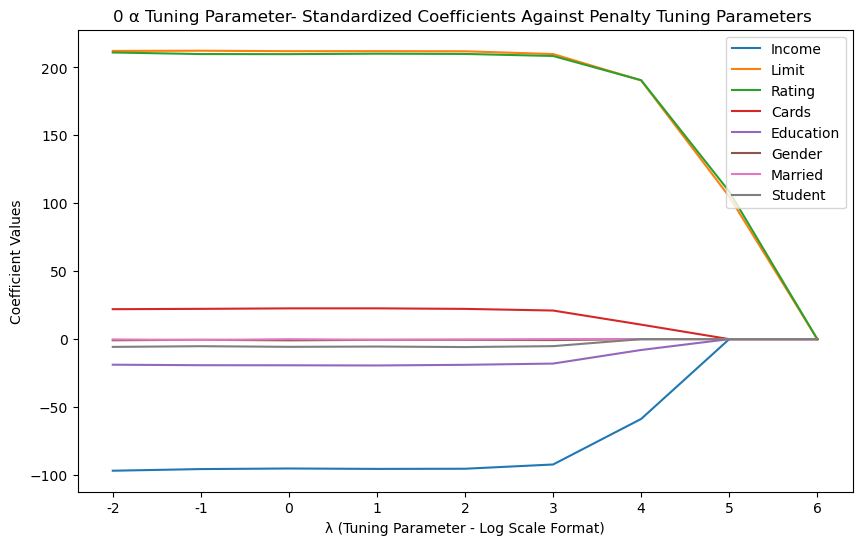

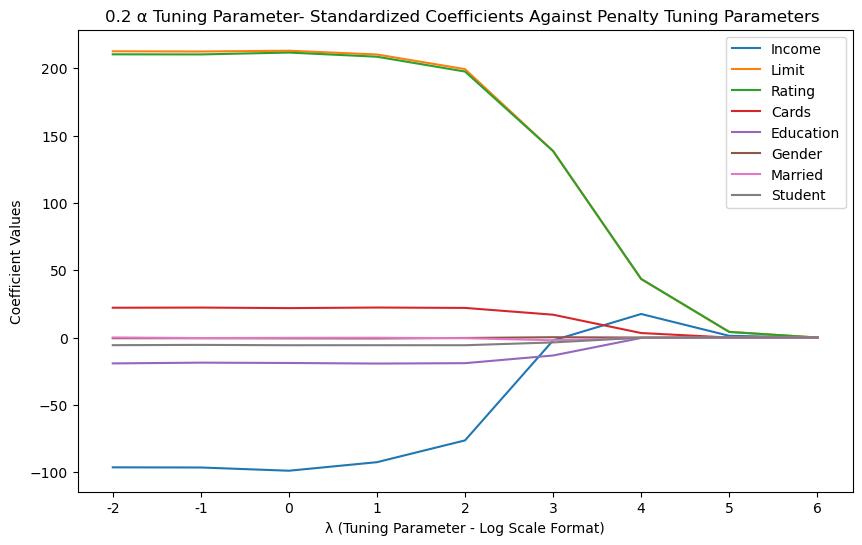

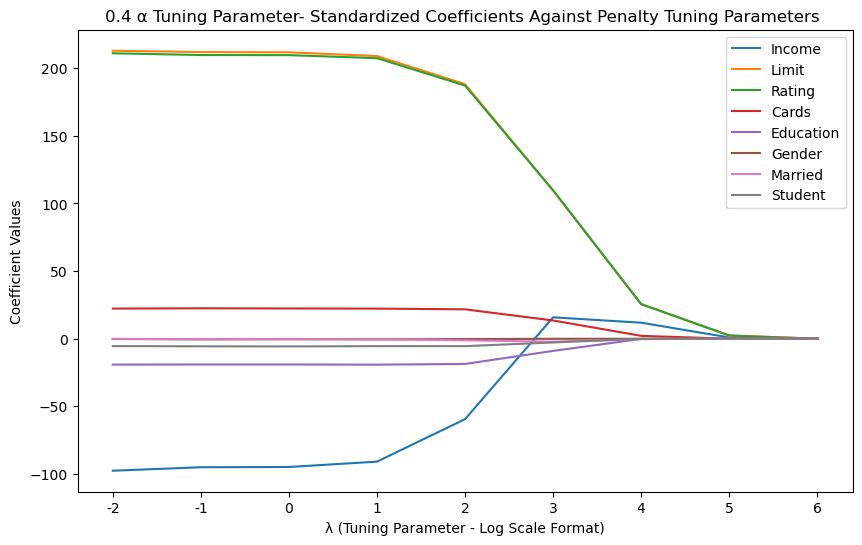

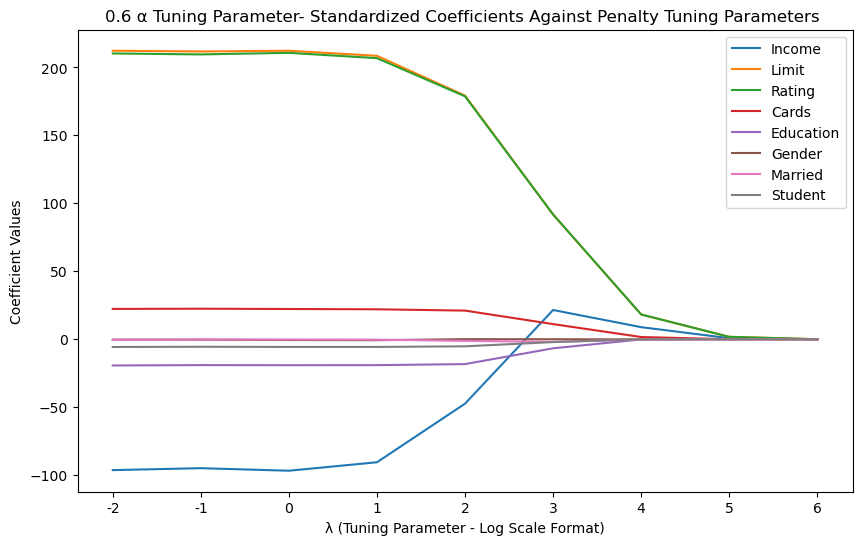

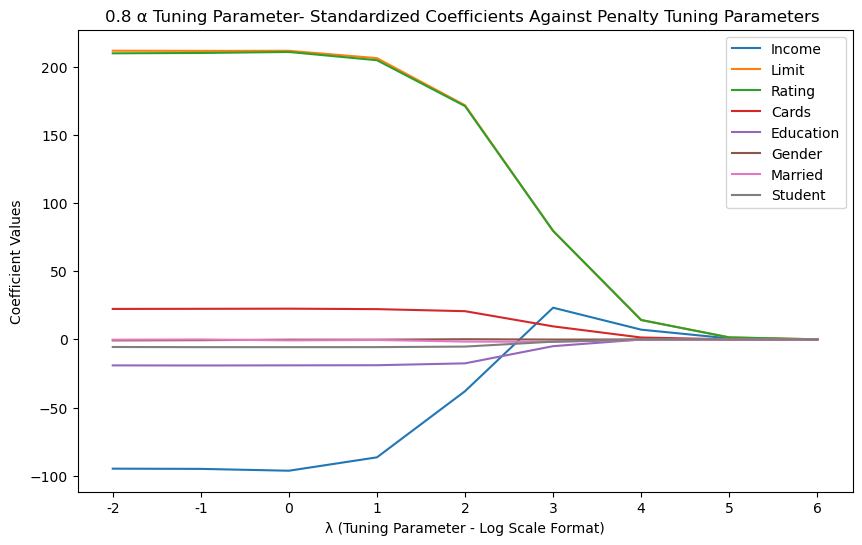

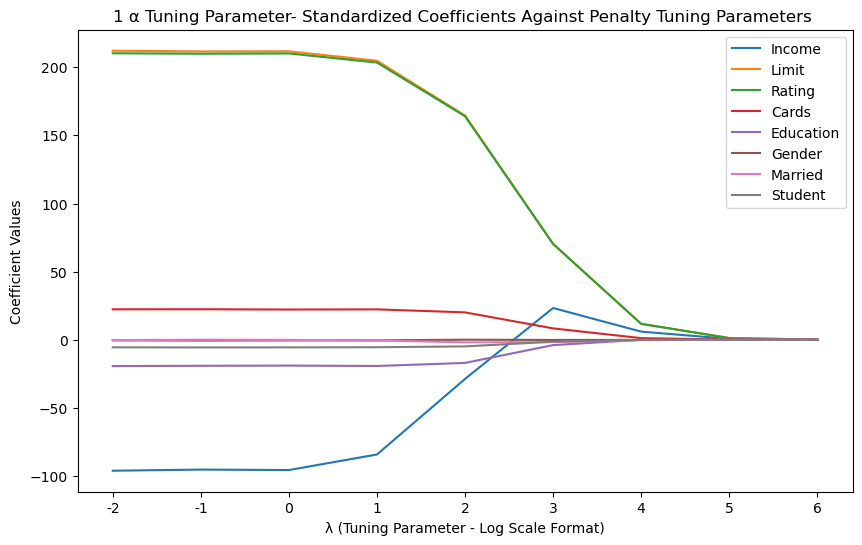

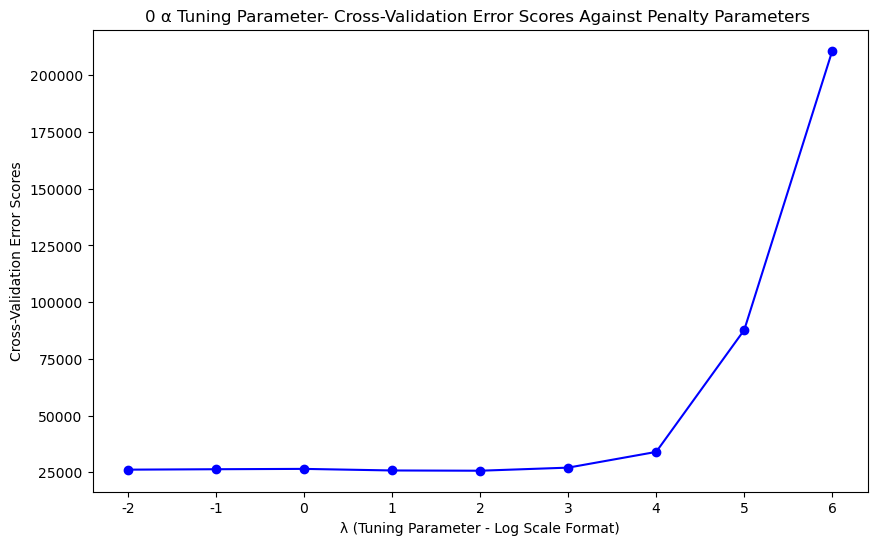

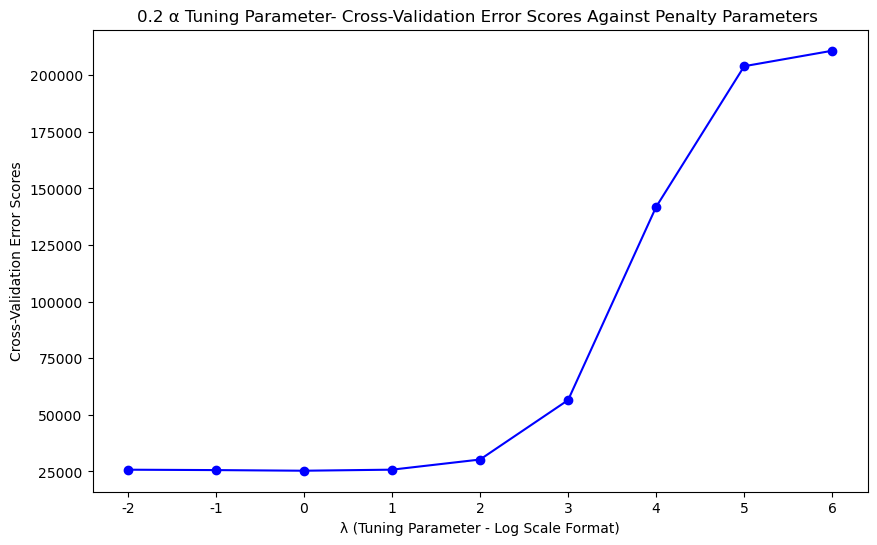

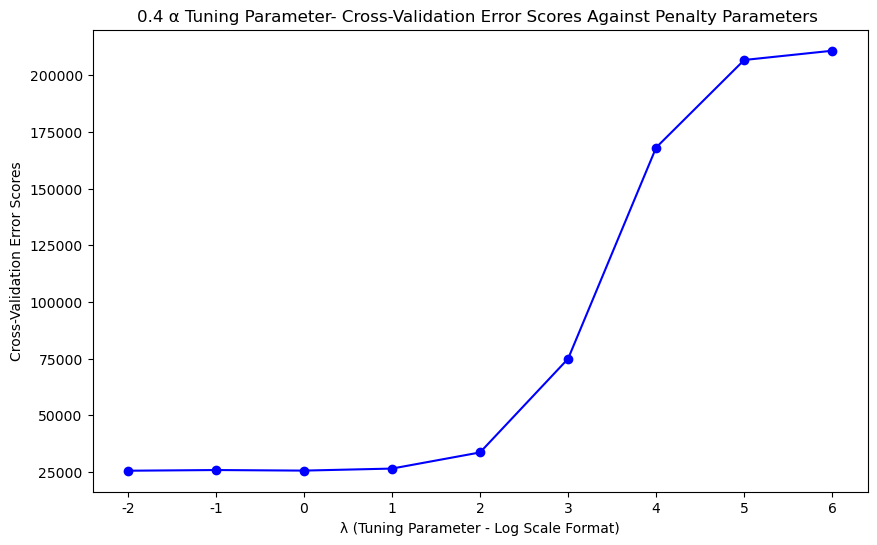

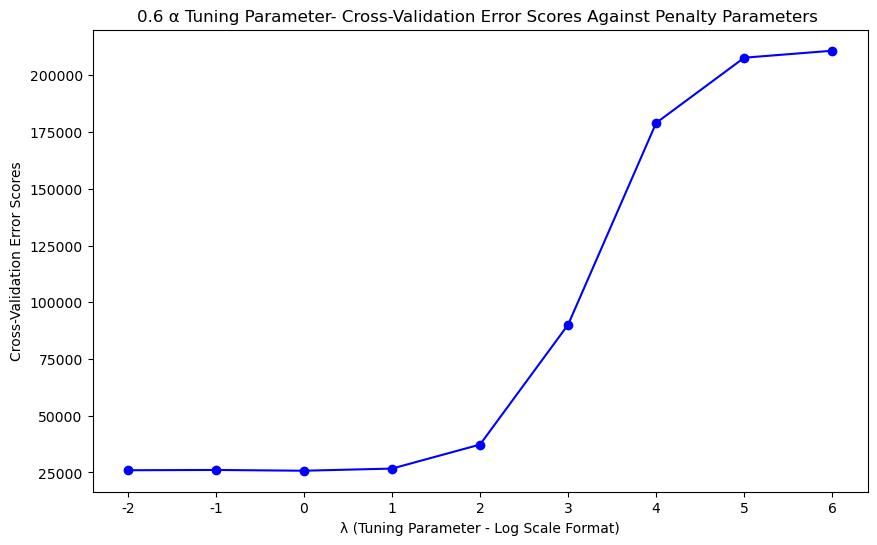

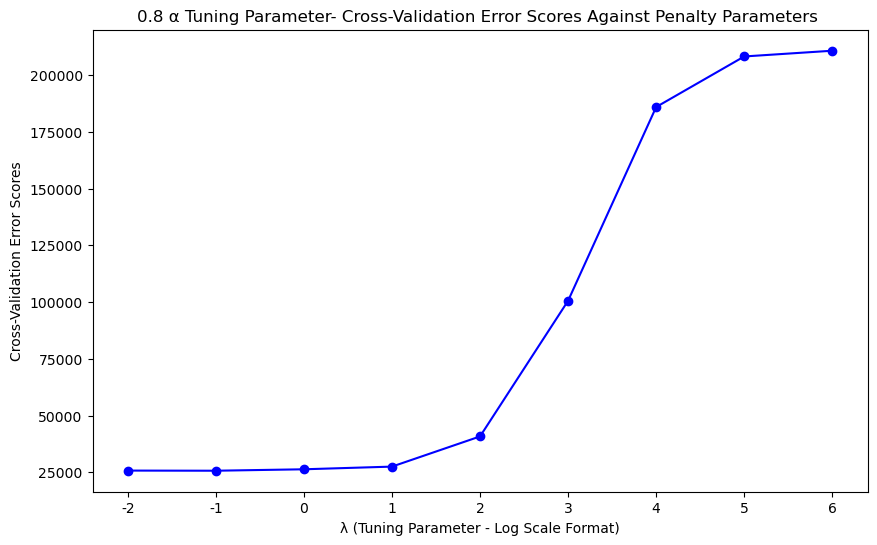

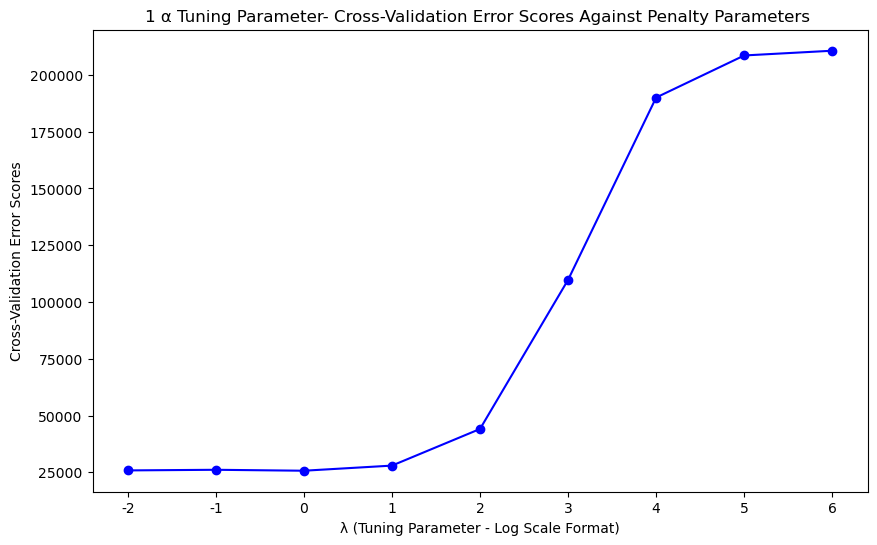

The lowest cross-validation error score achieved: 25339.384251453877
Alpha tuning parameter used 0.2
The lambda parameter that resulted in the lowest cross-validation score: 1


In [4]:
#Starting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

# Deliverables Are Located Below
# __________________________________________________________________
# __________________________________________________________________


#The previous assignment was used as a template
#Similar early logic exists
#Here, we are temporarily turning the csv data into a data frame

filename = "Credit_N400_p9.csv"
advertising_df = pd.read_csv(filename)

#This dataframe is quickly split between the features that will be used for x

x_features_df = advertising_df.copy(deep = True)


#Our goal is to determine credit card balance which is separated into its own df here

y_features_df = x_features_df.pop("Balance") 


#In this part the categorical columns are converted to allow them to be used for the upcoming alogirthms
x_features_df = pd.get_dummies(x_features_df, columns = ["Gender"], drop_first=True, dtype=int)

x_features_df = pd.get_dummies(x_features_df, columns = ["Married"], drop_first=True, dtype=int)

x_features_df = pd.get_dummies(x_features_df, columns = ["Student"], drop_first=True, dtype=int)

#This simply shows that the columns were converted and the original columns are gone
#Earlier the df was place into a deep copy of the original information so the original form exists too
x_features_df.head()


#For the purposes of the assignment, we are using ridge regression
#which requires standardization of the data
y_standardized = y_features_df - y_features_df.mean()


##The TA pointed out that encoded features need to be standardized as well
X_standardized = (x_features_df - x_features_df.mean()) / x_features_df.std()





#In the previous assignment a column of 1s was created for Beta 0
#This time it is not necessary
x_standardized_add1 = X_standardized




#This time the starting learning rate is 10 ^ -5
learning_rate_alpha = 10 ** -5

#This is the information of our penalty term lambda
tuning_parameter = 10 ** -2
tuning_parameters_set = [10**-2,10**-1,10**0,10**1,10**2,10**3,10**4,10**5,10**6]
#tuning_parameter = 0


k_fold = 5  

#We get the total number of observations involved
observations_N = len(X_standardized)

#We note the total number of features too
feature_total_p = len(x_standardized_add1.columns)

#The dataframes are converted to numpy arrays to allow for the matrix math that is going to be involved
X = x_standardized_add1.to_numpy()



y = y_standardized.to_numpy()

#This is represents the observation to fold split for the k fold operations
k_N_Splits = observations_N // k_fold 


#Like before, it must be noted that a standardized coefficients are always in a range between -1 and +1"
#Therefore, we use this information again for assignment 2
#Random is once again used to give us a random initial beta, -1 and 1 are used as a range
#This is relevant for the iteration loop that will occur in the later logic of the code

#initial_beta = np.random.uniform(-1, 1, feature_total_p)
initial_beta = np.random.uniform(-1, 1, feature_total_p)


#This is a intermediary holder for the beta information

intermediary_beta = initial_beta

#Vector param beta will act as the final ideal once the loop logic is exited
#This is primariy here to keep the logic easy to follow nd concise

#Placeholder until final values are estbalished
vector_param_beta = initial_beta

#variable to keep track of all beta resuls for graphing
record_of_v_beta = []


#variable to keep track of the cost history for graphing
record_of_cost = []

#The iteration loop size is set to 100,000 this time around

iter_loops = 1_000

b_k_set = np.sum(X**2, axis=0)
beta_loop_length = len(intermediary_beta)

def tuning_cv_loop_elastic(elastic_tp):
    # This will hold all the cv error and beta scores
    cross_validation_account_final = []
    vector_parameter_beta_final = []
    cross_validation_beta_account_final = []

    # Loop through each penalty value
    for current_tuning_parameter in tuning_parameters_set:
        # Set the current penalty term
        tuning_parameter = current_tuning_parameter
        # Randomly reorder observations
        random_reorder = np.random.permutation(observations_N)
        cross_validation_account = []  # Track CV errors
        cross_validation_beta_account = []  # Track beta values
        
        # Loop through all folds with the current penalty value
        for fold in range(k_fold):
            intermediary_beta = initial_beta.copy()  # Reset beta for each iteration
            
            # Observation placement after random reorganization
            beg_index = fold * k_N_Splits
            end_index = (fold + 1) * k_N_Splits
            validation_unit = random_reorder[beg_index:end_index]
            
            # Validation set
            X_validation_set = X[validation_unit]
            y_validation_set = y[validation_unit]
            
            # Training set
            X_training_set = np.delete(X, validation_unit, axis=0)
            y_training_set = np.delete(y, validation_unit, axis=0)

            # Batch gradient descent logic with Algorithm 1 updates
            for iter_c in range(iter_loops):
                for k_current in range(beta_loop_length):
                    X_k_current = X_training_set[:, k_current]
                    
                    # Algorithm 1: Calculate a_k
                    a_k = np.dot(X_k_current, y_training_set - np.dot(X_training_set, intermediary_beta) + X_k_current * intermediary_beta[k_current])
                    
                    # Update intermediary_beta[k_current] using Algorithm 1 conditions
                    if abs(a_k) > tuning_parameter * (1 - elastic_tp) / 2:
                        intermediary_beta[k_current] = (
                            np.sign(a_k) * max(abs(a_k) - tuning_parameter * (1 - elastic_tp) / 2, 0)
                            / (b_k_set[k_current] + tuning_parameter * elastic_tp)
                        )
                    else:
                        intermediary_beta[k_current] = 0

            # Predict validation set output
            y_validation_set_predicted = np.dot(X_validation_set, intermediary_beta)
            # Calculate validation error
            validation_error = np.sum((y_validation_set - y_validation_set_predicted) ** 2) / len(y_validation_set)
            
            # Append validation error and beta values for this fold
            cross_validation_account.append(validation_error)
            cross_validation_beta_account.append(intermediary_beta.copy())
        
        # After cross-validation loop, calculate mean CV error for current tuning parameter
        cross_validation_error = np.mean(cross_validation_account)
        cross_validation_account_final.append(cross_validation_error)
        vector_parameter_beta_final.append(intermediary_beta.copy())
        cross_validation_beta_account_final.append(np.mean(cross_validation_beta_account, axis=0))

    print(cross_validation_account_final)
    return cross_validation_account_final, vector_parameter_beta_final, cross_validation_beta_account_final










elastic_tuning_parameter_set = [0, .2, .4, .6, .8,  1]
cross_validation_account_final=[]
vector_parameter_beta_final=[]
cross_validation_beta_account_final=[]

etp_cross_validation_account_final = []
etp_vector_parameter_beta_final = []
etp_cross_validation_beta_account_final = []
for elastic_tuning_parameter in elastic_tuning_parameter_set:
    elastic_tp = elastic_tuning_parameter
    cross_validation_account_final, vector_parameter_beta_final, cross_validation_beta_account_final = tuning_cv_loop_elastic(elastic_tp)
    etp_cross_validation_account_final.append(cross_validation_account_final)
    etp_vector_parameter_beta_final.append(vector_parameter_beta_final)
    etp_cross_validation_beta_account_final.append(cross_validation_beta_account_final)


print(etp_vector_parameter_beta_final[0])

print(etp_vector_parameter_beta_final[1])

print(etp_vector_parameter_beta_final[2])



# __________________________________________________________________
# __________________________________________________________________

print(tuning_parameters_set)

def coeffecientsvptp(current_vector_param_b, graph_title):
    
    current_vector_param_b = np.array(current_vector_param_b)
    
    tp_log_set = [-2,-1,0,1,2,3,4,5,6]

    plt.figure(figsize=(10, 6))

    #Using the beta values found at each penalty parameter a graph is made. Labels show a beta for each specific column
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,0], label="Income")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,1], label="Limit")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,2], label="Rating")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,3], label="Cards")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,4], label="Education")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,5], label="Gender")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,6], label="Married")
    plt.semilogx(tuning_parameters_set, current_vector_param_b[:,7], label="Student")
    plt.xticks(ticks=tuning_parameters_set, labels=tp_log_set)
    plt.xlabel('λ (Tuning Parameter - Log Scale Format)')
    plt.ylabel('Coefficient Values')
    #plt.title('Standardized Coefficients Against Penalty Tuning Parameters')
    plt.title(graph_title)
    plt.legend(loc=1)
    plt.show()

for current_graph_etp in range(len(elastic_tuning_parameter_set)):
    current_vector_param_b = etp_cross_validation_beta_account_final[current_graph_etp]
    
    graph_title = str(elastic_tuning_parameter_set[current_graph_etp]) + " α Tuning Parameter- Standardized Coefficients Against Penalty Tuning Parameters "
    coeffecientsvptp(current_vector_param_b,  graph_title)
    

# __________________________________________________________________
# __________________________________________________________________

def errorvpenaltyperetp(cv_account_current, graph_title):
    tp_log_set = [-2,-1,0,1,2,3,4,5,6]
    #This graph shows the cross validation error scores across all of the penalty terms
    plt.figure(figsize=(10, 6))
    plt.semilogx(tuning_parameters_set, cv_account_current, 'bo-')
    plt.xticks(ticks=tuning_parameters_set, labels=tp_log_set)
    plt.xlabel('λ (Tuning Parameter - Log Scale Format)')
    plt.ylabel('Cross-Validation Error Scores')
    #plt.title('Cross-Validation Error Scores Against Penalty Parameters')
    plt.title(graph_title)
    plt.show()

for current_graph_etp in range(len(elastic_tuning_parameter_set)):
    current_vector_param_b = etp_cross_validation_account_final[current_graph_etp]
    
    graph_title = str(elastic_tuning_parameter_set[current_graph_etp]) + " α Tuning Parameter- Cross-Validation Error Scores Against Penalty Parameters "
    errorvpenaltyperetp(current_vector_param_b,  graph_title)

lowest_cross_validation_errors = []
placeholder_cve = min(etp_cross_validation_account_final[0])


placerholder_etp_position = 0

                 
for current_etp in range(len(elastic_tuning_parameter_set)):
    lowest_cross_validation_error = min(etp_cross_validation_account_final[current_etp])
    if lowest_cross_validation_error < placeholder_cve:
                      placeholder_cve = lowest_cross_validation_error
                      placerholder_etp_position = current_etp
print("The lowest cross-validation error score achieved: " + str(placeholder_cve))
print("Alpha tuning parameter used " + str(elastic_tuning_parameter_set[placerholder_etp_position]))

#This lowest cross validation error score is used to get the the lambda parameter used to achieve this score
tuning_parameter_lowest_cv = 0

cva_final = etp_cross_validation_account_final[placerholder_etp_position]
for i in range(len(cva_final)):
    if cva_final[i] == placeholder_cve:
        tuning_parameter_lowest_cv = tuning_parameters_set[i]

print("The lambda parameter that resulted in the lowest cross-validation score: " + str(tuning_parameter_lowest_cv))
#print(tuning_parameter_lowest_cv)


# __________________________________________________________________
# __________________________________________________________________

In [ ]:
# __________________________________________________________________
# __________________________________________________________________